In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
len(x_train)

60000

In [4]:
len(x_test)

10000

In [5]:
x_train[0].shape

(28, 28)

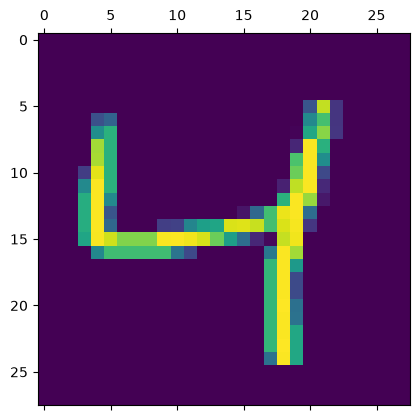

In [6]:
plt.matshow(x_train[2])

In [7]:
y_train[2]

np.uint8(4)

In [8]:
y_train[:9]

array([5, 0, 4, 1, 9, 2, 1, 3, 1], dtype=uint8)

In [9]:
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train_flattened=x_train.reshape(len(x_train),28*28)
x_test_flattened=x_test.reshape(len(x_test),28*28)

x_train_flattened.shape

(60000, 784)

In [10]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Fit the model
model.fit(x_train_flattened, y_train, epochs=5)

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8766 - loss: 0.4740
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9151 - loss: 0.3036
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9207 - loss: 0.2829
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9239 - loss: 0.2729
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9261 - loss: 0.2665


In [11]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9253 - loss: 0.2671


[0.2670873701572418, 0.9253000020980835]

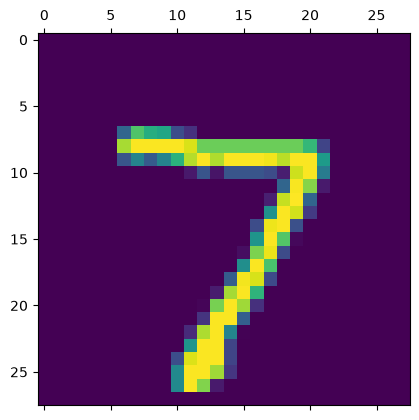

In [12]:
plt.matshow(x_test[0])

In [13]:
y_predicted=model.predict(x_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.83393527e-02, 3.56320527e-07, 8.18919465e-02, 9.45083201e-01,
       2.32623145e-03, 1.17043704e-01, 2.54618544e-06, 9.99780297e-01,
       1.12886943e-01, 6.21185422e-01], dtype=float32)

In [14]:
np.argmax(y_predicted[0])

np.int64(7)

In [15]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [16]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [17]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 956,    0,    2,    1,    0,    7,    7,    4,    2,    1],
       [   0, 1109,    4,    1,    0,    1,    4,    2,   14,    0],
       [   3,    9,  927,   14,    6,    5,   12,   12,   41,    3],
       [   3,    0,   22,  904,    0,   32,    3,   14,   26,    6],
       [   1,    1,    5,    1,  906,    0,   14,    5,   10,   39],
       [   7,    2,    2,   22,    6,  793,   17,    5,   30,    8],
       [   9,    3,    5,    1,    7,   14,  916,    2,    1,    0],
       [   1,    5,   24,    5,    6,    0,    0,  955,    2,   30],
       [   5,    6,    6,   19,    9,   25,    9,   12,  877,    6],
       [   9,    7,    2,   10,   24,    7,    0,   31,    9,  910]],
      dtype=int32)>

Text(95.83333333333333, 0.5, 'Truth')

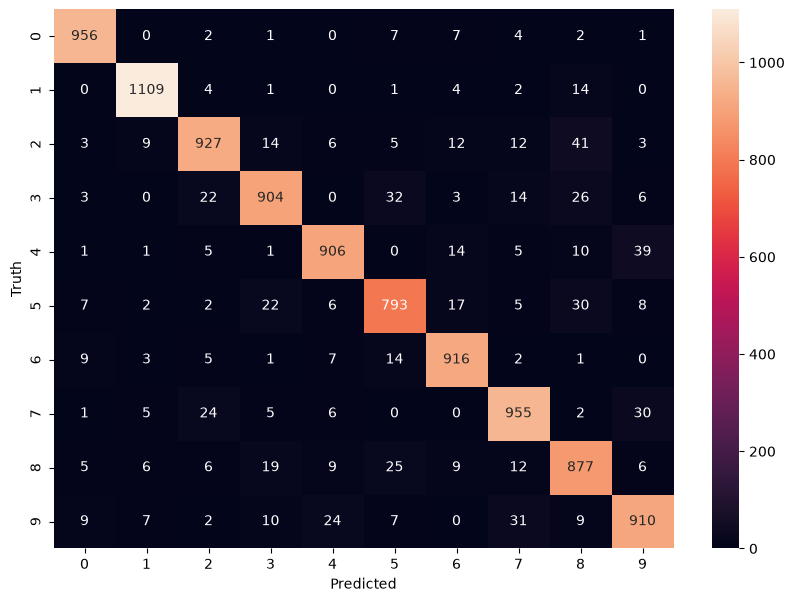

In [18]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [19]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')

])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Fit the model
model.fit(x_train_flattened, y_train, epochs=5)

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9216 - loss: 0.2751
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9624 - loss: 0.1246
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9738 - loss: 0.0866
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9794 - loss: 0.0670
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9840 - loss: 0.0525


In [20]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.0788


[0.07876358926296234, 0.9765999913215637]

In [23]:
model.save("./saved_model.keras")

In [31]:
model = tf.keras.models.load_model("./saved_model.keras")

In [33]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\taimo\AppData\Local\Temp\tmpecilxztl\assets


INFO:tensorflow:Assets written to: C:\Users\taimo\AppData\Local\Temp\tmpecilxztl\assets


Saved artifact at 'C:\Users\taimo\AppData\Local\Temp\tmpecilxztl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2652297548176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2652297548944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2652297548368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2652297549136: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [34]:
len(tflite_model)

319796

In [37]:
converter=tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations=[tf.lite.Optimize.DEFAULT]
tflite_quant_model=converter.convert()

INFO:tensorflow:Assets written to: C:\Users\taimo\AppData\Local\Temp\tmpvv34v5su\assets


INFO:tensorflow:Assets written to: C:\Users\taimo\AppData\Local\Temp\tmpvv34v5su\assets


Saved artifact at 'C:\Users\taimo\AppData\Local\Temp\tmpvv34v5su'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2652297548176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2652297548944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2652297548368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2652297549136: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [38]:
len(tflite_quant_model)

85864

In [39]:
with open("tflite_model.tflite","wb") as f:
  f.write(tflite_model)

with open("tflite_quant_model.tflite","wb") as f:
  f.write(tflite_quant_model)

In [ ]:

import tensorflow as tf
import tensorflow_model_optimization as tfmot

model = tf.keras.models.load_model("./saved_model.keras")

quantize_model = tfmot.quantization.keras.quantize_model
q_aware_model = quantize_model(model)


In [ ]:
len(tflite_model)

In [ ]:
len(tflite_quant_model)

In [ ]:
with open("tflite_model.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
with open("tflite_quant_model.tflite", "wb") as f:
    f.write(tflite_quant_model)

In [ ]:
import tensorflow_model_optimization as tfmot

quantize_model = tfmot.quantization.keras.quantize_model

# q_aware stands for for quantization aware.
q_aware_model = quantize_model(model)

# `quantize_model` requires a recompile.
q_aware_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

q_aware_model.summary()

In [ ]:
q_aware_model.fit(X_train, y_train, epochs=1)

In [ ]:
q_aware_model.evaluate(X_test, y_test)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_qaware_model = converter.convert()

In [ ]:
len(tflite_qaware_model)

In [ ]:
with open("tflite_qaware_model.tflite", 'wb') as f:
    f.write(tflite_qaware_model)